## Brightness and LIME image explainer

In [1]:
import pickle

import matplotlib.pyplot as plt
import numpy as np
from skimage.segmentation import mark_boundaries
from skimage.io import imsave, imshow
from astroExplain.image.neighbors import Neighbors
from astroExplain.image.explanation import TellMeWhy
from sdss.utils.managefiles import FileDirectory


In [2]:
def segment(image, sigma, compactness, nsegments):

    slic_parameters = {"sigma": sigma, "compactness": compactness}

    nghs = Neighbors(
        image=image,
        number_segments=nsegments,
        slic_parameters=slic_parameters,
        random_seed=0,
    )

    image_with_boundaries = mark_boundaries(
        nghs.image,
        nghs.segments,
        color=(1, 1, 1),
        outline_color=(1, 1, 1),
    )

    plt.clf()
    # plt.imshow(image_with_boundaries)
    imshow(image_with_boundaries)
    plt.axis("off")
    plt.tight_layout()

    save_to = "/home/edgar/explain-me-why/sections/figures/lime/hoag_object"
    fname = f"segments_{nsegments}_sigma_{sigma}_compactness_{compactness}"
    # imsave(f"{save_to}/{fname}.pdf", image_with_boundaries)
    # imsave(f"{save_to}/{fname}.png", image_with_boundaries)
    # plt.savefig(f"{save_to}/{fname}.pdf")
    # plt.savefig(f"{save_to}/{fname}.png")

    return image_with_boundaries, nghs

In [5]:
data = "../../data/images"
# load data
image = plt.imread(f"{data}/weird.jpg") / 255.0

/tmp/ipykernel_217637/3355601266.py:1: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(image)


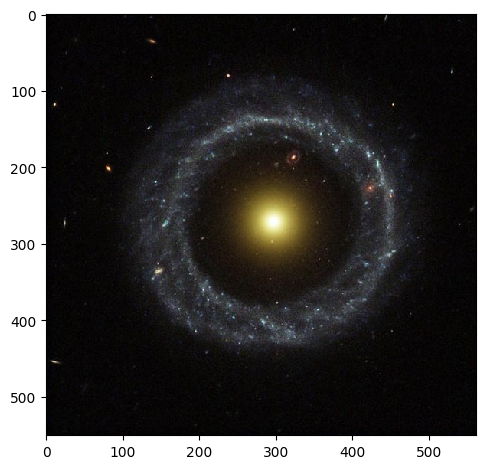

In [6]:
imshow(image)

## Different segmentations

/tmp/ipykernel_217637/267072217.py:21: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(image_with_boundaries)


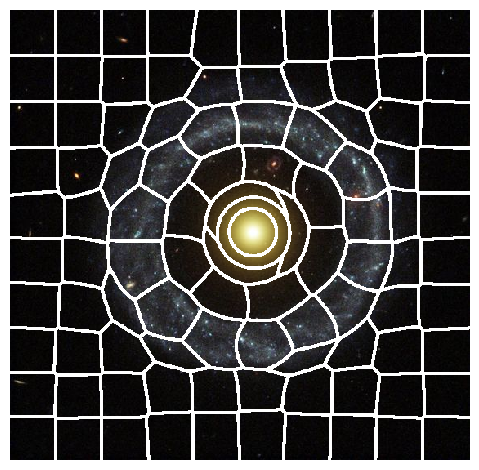

In [7]:
image_with_boundaries, nghs = segment(
    image, sigma=16, compactness=10, nsegments=100
)

In [8]:
perturbations = nghs.get_neighbors(100, None)

In [20]:
for idx, perturbation in enumerate(perturbations):

    # plt.clf()

    ngh_with_boundaries = mark_boundaries(
        perturbation,
        nghs.segments,
        color=(1, 1, 1),
        outline_color=(1, 1, 1),
    )

    # plt.axis('off')

    # imshow(ngh_with_boundaries)

    # plt.tight_layout()
    # plt.show()

    save_to = "/home/edgar/explain-me-why/sections/figures/lime/hoag_object"

    fname = f"neighbor_{idx}_segments_{100}_sigma_{16}_compactness_{10}"
    # plt.savefig(f"{save_to}/{fname}.pdf")
    # plt.savefig(f"{save_to}/{fname}.png")
    imsave(f"{save_to}/{fname}.png", ngh_with_boundaries)

Lossy conversion from float64 to uint8. Range [0, 1]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float64 to uint8. Range [0, 1]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float64 to uint8. Range [0, 1]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float64 to uint8. Range [0, 1]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float64 to uint8. Range [0, 1]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float64 to uint8. Range [0, 1]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float64 to uint8. Range [0, 1]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float64 to uint8. Range [0, 1]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float64 to uint8. Range [0

# Explanations

Get heat map of explanation


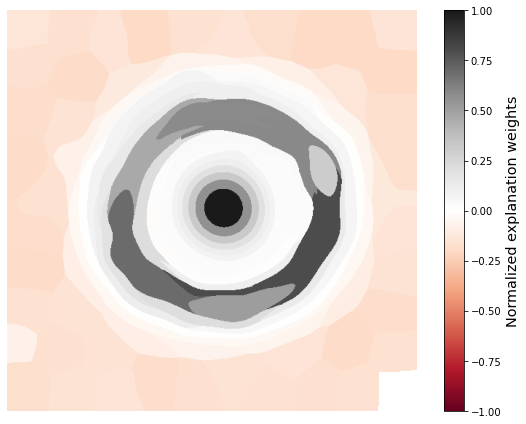

In [31]:
explanation_directory = "/home/edgar/xai-astronomy/data/images/weird/"
# explanation_file = "weird_hide_none_base_mean_100_compactness_10"
# explanation_file = "weird_hide_0.08_base_mean_100_compactness_100"
# explanation_file = "weird_hide_0.08_base_mean_100_compactness_10"
explanation_file = "weird_hide_0.08_base_mean_100_compactness_1"

with open(f"{explanation_directory}/{explanation_file}.pkl", "rb") as file:

    explainer = pickle.load(file)
    why = TellMeWhy(explainer)

weights_map = why.get_heatmap()
weights_map *= 1 / np.nanmax(np.abs(weights_map))
plt.figure(figsize=(8, 6))
# fig, axs = plt.subplots(nrows=1, ncols=2 ,tight_layout=True)
# axs[0].imshow(image_with_boundaries)
# axs[1].imshow(weights_map, cmap="RdGy", vmin=-1, vmax=1)
# fig.colorbar(axs[1])
plt.clf()
plt.imshow(weights_map, cmap="RdGy", vmin=-1, vmax=1)
cbar = plt.colorbar(
    # label="Normalized explanation weights"
)
cbar.ax.set_ylabel(
    "Normalized explanation weights",
    # rotation=270,
    fontsize="x-large",
)
plt.axis("off")
plt.tight_layout()

save_to = "/home/edgar/explain-me-why/sections/figures/lime/hoag_object"
# plt.savefig(f"{save_to}/{explanation_file}.pdf")
plt.savefig(f"{save_to}/{explanation_file}.png")
# imsave(f"{save_to}/{explanation_file}.png", weights_map)

In [32]:
tata = plt.imread(f"{save_to}/{explanation_file}.png")

# Perturbation notebook

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from skimage.segmentation import mark_boundaries
from skimage.io import imsave, imshow
from astroExplain.image.neighbors import Neighbors

In [ ]:
def mask_pertrubed_sps(
    segments: np.array, on_off_super_pixels: np.array
) -> np.array:
    """
    Obtain a mask with the number of the segment for perturbed
    super pixels. The non-perturbed super pixels has a segment
    number of zero. Remember that the number of the original
    segments range from 1 to the number of segments
    """
    new_segments = segments.copy()
    for idx_sp, on_off in enumerate(on_off_super_pixels):

        if on_off == 1:
            # segments range from 0 to the number of segments
            # that is why I use idx_sp + 1
            mask_on_sp = np.where(segments == idx_sp + 1, True, False)

            new_segments[mask_on_sp] = 0

    return new_segments

/tmp/ipykernel_218061/1663741821.py:4: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(image)


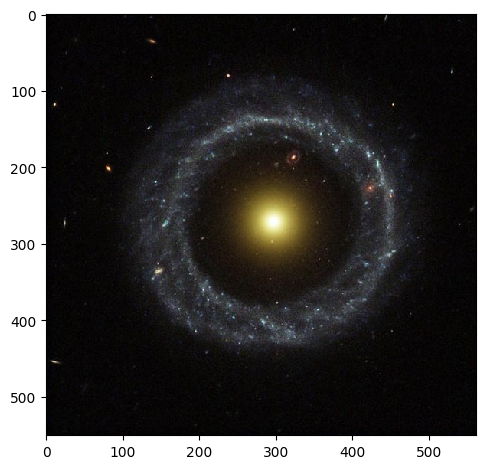

In [ ]:
data = "../..//data/images"
# load data
image = plt.imread(f"{data}/weird.jpg") / 255.0
imshow(image)

In [ ]:
slic_parameters = {"sigma": 16, "compactness": 10}
neighbors = Neighbors(
    image=image,
    number_segments=100,
    slic_parameters=slic_parameters,
    random_seed=0,
)

In [ ]:
perturbed_images, on_off_sp_perturbation = neighbors.get_neighbors(10, None)

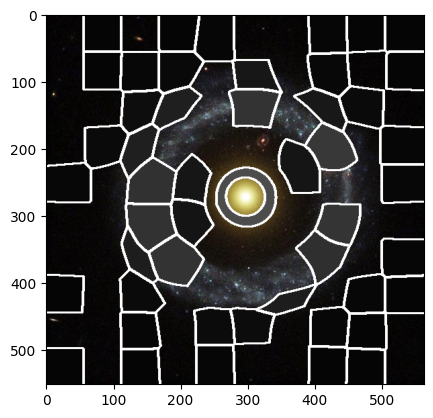

In [ ]:
n = 2
new_segments = mask_pertrubed_sps(
    neighbors.segments, on_off_sp_perturbation[n]
)
image_with_boundaries = mark_boundaries(
    perturbed_images[n],
    new_segments,
    color=(1, 1, 1),
    outline_color=(1, 1, 1),
)
plt.imshow(image_with_boundaries)

In [ ]:
save_to = "/home/edgar/explain-me-why/sections/figures/lime/hoag_object"

for idx, perturbation in enumerate(perturbed_images[1:]):

    new_segments = mask_pertrubed_sps(
        neighbors.segments, on_off_sp_perturbation[idx + 1]
    )

    image_with_boundaries = mark_boundaries(
        perturbation,
        new_segments,
        color=(1, 1, 1),
        outline_color=(1, 1, 1),
    )

    # imshow(ngh_with_boundaries)

    fname = f"neighbor_{idx+1}_" f"segments_{100}_sigma_{16}_compactness_{10}"
    imsave(f"{save_to}/{fname}.png", image_with_boundaries)

Lossy conversion from float64 to uint8. Range [0, 1]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float64 to uint8. Range [0, 1]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float64 to uint8. Range [0, 1]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float64 to uint8. Range [0, 1]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float64 to uint8. Range [0, 1]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float64 to uint8. Range [0, 1]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float64 to uint8. Range [0, 1]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float64 to uint8. Range [0, 1]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float64 to uint8. Range [0